In [ ]:
# CELL 1: Environment Setup & GPU Verification
import torch, platform
print("=" * 60)
print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device       : {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("WARNING: No GPU. Runtime > Change runtime type > GPU")
    device = torch.device("cpu")
print("=" * 60)

PyTorch version  : 2.11.0+cu128
CUDA available   : True
GPU device       : Tesla T4


In [ ]:
# CELL 2 (FINAL): Packages + NumPy pin (LAST) + peft removal + Drive mount
import subprocess, sys, os

def pip_run(args, label):
    print(f"{label} ...")
    result = subprocess.run([sys.executable, "-m", "pip"] + args, capture_output=True, text=True)
    ok = result.returncode == 0
    print(f"  {'✓' if ok else '✗'} {label} {'done' if ok else 'FAILED'}")
    if not ok:
        print("\n".join(result.stderr.strip().split("\n")[-8:]))
    return ok

status = {}
status["transformers"] = pip_run(["install", "-q", "transformers==4.41.2"], "transformers")
status["datasets"]     = pip_run(["install", "-q", "datasets==2.19.1"], "datasets")
status["evaluate"]     = pip_run(["install", "-q", "evaluate==0.4.2"], "evaluate")
status["accelerate"]   = pip_run(["install", "-q", "accelerate==0.30.1"], "accelerate")
status["scikit-learn"] = pip_run(["install", "-q", "scikit-learn"], "scikit-learn")
status["pandas"]       = pip_run(["install", "-q", "pandas"], "pandas")
status["psutil"]       = pip_run(["install", "-q", "psutil"], "psutil")
status["codecarbon"]   = pip_run(["install", "-q", "codecarbon"], "codecarbon")
status["peft_removed"] = pip_run(["uninstall", "-y", "peft"], "removing unused peft (breaks Trainer import)")
status["numpy"]        = pip_run(["install", "-q", "numpy<2.0.0", "--force-reinstall"], "pinning numpy<2.0.0 (must be LAST)")

print("\n" + "=" * 60 + "\nINSTALL SUMMARY\n" + "=" * 60)
for pkg, ok in status.items():
    print(f"  {pkg:15s}: {'OK' if ok else 'FAILED'}")

check = subprocess.run(
    [sys.executable, "-c",
     "import numpy; print('numpy', numpy.__version__); "
     "import importlib.util; print('peft_present', importlib.util.find_spec('peft') is not None)"],
    capture_output=True, text=True
)
print(f"\nFresh-process check:\n{check.stdout.strip()}")
fresh_ok = "numpy 1." in check.stdout and "peft_present False" in check.stdout

if fresh_ok:
    import numpy as _np
    this_ok = _np.__version__.startswith("1.") and "peft" not in sys.modules
    if this_ok:
        from google.colab import drive
        drive.mount('/content/drive')
        PROJECT_ROOT = "/content/drive/MyDrive/EmberSieve"
        for sub in ["checkpoints", "results", "logs", "reports", "configs"]:
            os.makedirs(os.path.join(PROJECT_ROOT, sub), exist_ok=True)
        print("\nDrive mounted, folders ready. CELL 2 COMPLETE.")
    else:
        print("\nStale state in memory — restarting runtime (normal, not a crash).")
        import IPython
        IPython.Application.instance().kernel.do_shutdown(restart=True)
else:
    print("\nERROR: check install logs above.")

transformers ...
  ✓ transformers done
datasets ...
  ✓ datasets done
evaluate ...
  ✓ evaluate done
accelerate ...
  ✓ accelerate done
scikit-learn ...
  ✓ scikit-learn done
pandas ...
  ✓ pandas done
psutil ...
  ✓ psutil done
codecarbon ...
  ✓ codecarbon done
removing unused peft (breaks Trainer import) ...
  ✓ removing unused peft (breaks Trainer import) done
pinning numpy<2.0.0 (must be LAST) ...
  ✓ pinning numpy<2.0.0 (must be LAST) done

INSTALL SUMMARY
  transformers   : OK
  datasets       : OK
  evaluate       : OK
  accelerate     : OK
  scikit-learn   : OK
  pandas         : OK
  psutil         : OK
  codecarbon     : OK
  peft_removed   : OK
  numpy          : OK

Fresh-process check:
numpy 1.26.4
peft_present False
Mounted at /content/drive

Drive mounted, folders ready. CELL 2 COMPLETE.


In [ ]:
# CELL 3: Global Configuration
import os, json, random, numpy as np, torch

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(SEED)

HPARAMS = {
    "optimizer": "adamw_torch", "weight_decay": 0.01, "batch_size": 16,
    "learning_rate": 2e-5, "warmup_ratio": 0.10, "lr_scheduler_type": "linear",
    "num_train_epochs": 5, "max_seq_length": 128, "seed": SEED,
}
MODEL_CHECKPOINTS = {"bert-base": "bert-base-uncased", "distilbert": "distilbert-base-uncased"}

GLUE_TASK_CONFIG = {
    "cola":  {"keys": ("sentence", None),          "num_labels": 2, "problem_type": "single_label_classification", "metric": "matthews_correlation"},
    "sst2":  {"keys": ("sentence", None),          "num_labels": 2, "problem_type": "single_label_classification", "metric": "accuracy"},
    "mrpc":  {"keys": ("sentence1", "sentence2"),  "num_labels": 2, "problem_type": "single_label_classification", "metric": "accuracy_f1"},
    "stsb":  {"keys": ("sentence1", "sentence2"),  "num_labels": 1, "problem_type": "regression",                  "metric": "pearson_spearman"},
    "qqp":   {"keys": ("question1", "question2"),  "num_labels": 2, "problem_type": "single_label_classification", "metric": "accuracy_f1"},
    "mnli":  {"keys": ("premise", "hypothesis"),   "num_labels": 3, "problem_type": "single_label_classification", "metric": "accuracy"},
    "qnli":  {"keys": ("question", "sentence"),    "num_labels": 2, "problem_type": "single_label_classification", "metric": "accuracy"},
    "rte":   {"keys": ("sentence1", "sentence2"),  "num_labels": 2, "problem_type": "single_label_classification", "metric": "accuracy"},
    "wnli":  {"keys": ("sentence1", "sentence2"),  "num_labels": 2, "problem_type": "single_label_classification", "metric": "accuracy"},
}
GLUE_TASKS = list(GLUE_TASK_CONFIG.keys())
SPARSITY_LEVELS = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
TRACKED_METRICS = ["memory_size_mb", "latency_ms", "accuracy", "bits", "precision",
                    "recall", "f1_score", "throughput_samples_per_sec", "energy_consumption_kwh"]

PROJECT_ROOT = "/content/drive/MyDrive/EmberSieve"
PATHS = {k: os.path.join(PROJECT_ROOT, k) for k in ["checkpoints", "results", "logs", "reports", "configs"]}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(os.path.join(PATHS["configs"], "run_config.json"), "w") as f:
    json.dump({"hparams": HPARAMS, "models": MODEL_CHECKPOINTS, "glue_tasks": GLUE_TASKS,
               "sparsity_levels": SPARSITY_LEVELS, "tracked_metrics": TRACKED_METRICS}, f, indent=2)

print(f"GLUE tasks: {GLUE_TASKS}")
print(f"Sparsity levels: {SPARSITY_LEVELS}")
print(f"Device: {DEVICE}")
print("CELL 3 COMPLETE.")

GLUE tasks: ['cola', 'sst2', 'mrpc', 'stsb', 'qqp', 'mnli', 'qnli', 'rte', 'wnli']
Sparsity levels: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
Device: cuda
CELL 3 COMPLETE.


In [ ]:
# CELL 4: GLUE Data Loading & Tokenization (MNLI fix included)
import numpy
assert int(numpy.__version__.split(".")[0]) < 2, (
    f"NumPy {numpy.__version__} detected — re-run Cell 2 and restart the runtime."
)
print(f"NumPy version OK: {numpy.__version__}")

from datasets import load_dataset
from transformers import AutoTokenizer

_raw_dataset_cache = {}
_tokenizer_cache = {}

def load_glue_task(task_name):
    """Loads a raw GLUE dataset, aliasing MNLI's validation_matched -> validation
    (MNLI has no plain 'validation' split — it has matched/mismatched dev sets;
    we use 'matched' as the standard primary metric, per GLUE convention)."""
    if task_name in _raw_dataset_cache:
        return _raw_dataset_cache[task_name]
    print(f"Loading GLUE/{task_name} ...")
    raw = load_dataset("glue", task_name)
    if task_name == "mnli" and "validation" not in raw:
        raw["validation"] = raw["validation_matched"]
        print("  MNLI: aliased 'validation_matched' -> 'validation'")
    _raw_dataset_cache[task_name] = raw
    print(f"  train={len(raw['train'])}, validation={len(raw['validation'])}")
    return raw

def get_tokenizer(model_checkpoint):
    if model_checkpoint not in _tokenizer_cache:
        _tokenizer_cache[model_checkpoint] = AutoTokenizer.from_pretrained(model_checkpoint)
    return _tokenizer_cache[model_checkpoint]

def tokenize_task_dataset(task_name, model_checkpoint, max_length=None):
    if max_length is None:
        max_length = HPARAMS["max_seq_length"]
    raw = load_glue_task(task_name)
    tokenizer = get_tokenizer(model_checkpoint)
    key1, key2 = GLUE_TASK_CONFIG[task_name]["keys"]

    def preprocess(examples):
        if key2 is None:
            return tokenizer(examples[key1], truncation=True, max_length=max_length, padding="max_length")
        return tokenizer(examples[key1], examples[key2], truncation=True, max_length=max_length, padding="max_length")

    tokenized = raw.map(preprocess, batched=True)
    if "label" in tokenized["train"].column_names:
        tokenized = tokenized.rename_column("label", "labels")
    keep_cols = ["input_ids", "attention_mask", "labels"]
    if "token_type_ids" in tokenized["train"].column_names:
        keep_cols.insert(2, "token_type_ids")
    remove_cols = [c for c in tokenized["train"].column_names if c not in keep_cols]
    tokenized = tokenized.remove_columns(remove_cols)
    tokenized.set_format("torch")
    return tokenized

print("CELL 4 COMPLETE.")

NumPy version OK: 1.26.4
CELL 4 COMPLETE.


In [ ]:
# CELL 5: Model Loading & One-Shot Magnitude Pruning (OMP)
import torch.nn as nn
import torch.nn.utils.prune as prune
from transformers import AutoModelForSequenceClassification

def load_model_for_task(model_checkpoint, task_name):
    cfg = GLUE_TASK_CONFIG[task_name]
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint, num_labels=cfg["num_labels"], problem_type=cfg["problem_type"]
    )
    return model.to(DEVICE)

def get_prunable_modules(model):
    return [(m, "weight") for m in model.modules() if isinstance(m, nn.Linear)]

def apply_one_shot_magnitude_pruning(model, sparsity):
    if sparsity == 0.0:
        return model
    prune.global_unstructured(get_prunable_modules(model), pruning_method=prune.L1Unstructured, amount=sparsity)
    return model

def make_pruning_permanent(model):
    for module in model.modules():
        if isinstance(module, nn.Linear) and prune.is_pruned(module):
            prune.remove(module, "weight")
    return model

def compute_global_sparsity(model):
    total, zero = 0, 0
    for module in model.modules():
        if isinstance(module, nn.Linear):
            total += module.weight.numel()
            zero += (module.weight == 0).sum().item()
    return zero / total if total > 0 else 0.0

print("CELL 5 COMPLETE.")

CELL 5 COMPLETE.


In [ ]:
# CELL 6: GLUE Metrics Computation
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, matthews_corrcoef

def compute_classification_metrics(preds, labels):
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall": recall_score(labels, preds, average="weighted", zero_division=0),
        "f1_score": f1_score(labels, preds, average="weighted", zero_division=0),
    }

def compute_regression_metrics(preds, labels):
    preds, labels = preds.flatten(), labels.flatten()
    pearson_corr = pearsonr(preds, labels)[0]
    spearman_corr = spearmanr(preds, labels)[0]
    return {"pearson": pearson_corr, "spearman": spearman_corr,
            "accuracy": (pearson_corr + spearman_corr) / 2,
            "precision": float("nan"), "recall": float("nan"), "f1_score": float("nan")}

def compute_cola_metrics(preds, labels):
    return {"matthews_corrcoef": matthews_corrcoef(labels, preds), **compute_classification_metrics(preds, labels)}

def build_compute_metrics_fn(task_name):
    problem_type = GLUE_TASK_CONFIG[task_name]["problem_type"]
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        if problem_type == "regression":
            return compute_regression_metrics(logits, labels)
        preds = np.argmax(logits, axis=-1)
        return compute_cola_metrics(preds, labels) if task_name == "cola" else compute_classification_metrics(preds, labels)
    return compute_metrics

print("CELL 6 COMPLETE.")

CELL 6 COMPLETE.


In [ ]:
# CELL 7: System-Level Profiling
import time

def compute_memory_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    total_bytes += sum(b.numel() * b.element_size() for b in model.buffers())
    return total_bytes / (1024 ** 2)

def compute_bits(model, sparsity=0.0):
    nominal_bits = next(model.parameters()).element_size() * 8
    return {"nominal_bits": nominal_bits, "effective_bits": nominal_bits * (1 - sparsity)}

def measure_latency_throughput(model, tokenizer, batch_size=16, seq_length=128, n_warmup=5, n_iters=30):
    model.eval()
    dummy = {
        "input_ids": torch.randint(0, tokenizer.vocab_size, (batch_size, seq_length)).to(DEVICE),
        "attention_mask": torch.ones(batch_size, seq_length, dtype=torch.long).to(DEVICE),
    }
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(**dummy)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(n_iters):
            _ = model(**dummy)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        total = time.perf_counter() - start
    return {"latency_ms": (total / n_iters) * 1000, "throughput_samples_per_sec": (batch_size * n_iters) / total}

try:
    from codecarbon import EmissionsTracker
    _CODECARBON_AVAILABLE = True
except ImportError:
    _CODECARBON_AVAILABLE = False

def profile_model(model, tokenizer, sparsity=0.0):
    mem = compute_memory_size_mb(model)
    bits = compute_bits(model, sparsity)
    perf = measure_latency_throughput(model, tokenizer)
    return {"memory_size_mb": mem, **bits, **perf}

print(f"CELL 7 COMPLETE. (codecarbon available: {_CODECARBON_AVAILABLE})")

CELL 7 COMPLETE. (codecarbon available: True)


In [ ]:
# CELL 8: Fine-Tuning Function with Drive Checkpointing
import json
from transformers import TrainingArguments, Trainer

# Patch torch.load: PyTorch 2.6+ defaults weights_only=True, which blocks
# loading Trainer's own RNG-state checkpoints (numpy objects inside).
# Safe here since we only ever resume checkpoints WE generated ourselves.
_original_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _original_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

def get_checkpoint_dir(model_name, task_name, sparsity):
    sp_tag = f"sp{int(round(sparsity * 100)):03d}"
    return os.path.join(PATHS["checkpoints"], f"{model_name}__{task_name}__{sp_tag}")

def is_already_done(model_name, task_name, sparsity):
    return os.path.exists(os.path.join(get_checkpoint_dir(model_name, task_name, sparsity), "final_metrics.json"))

def load_saved_metrics(model_name, task_name, sparsity):
    with open(os.path.join(get_checkpoint_dir(model_name, task_name, sparsity), "final_metrics.json")) as f:
        return json.load(f)

def fine_tune_model(model, tokenized_dataset, task_name, model_name, sparsity, output_dir=None, resume_from_checkpoint=None):
    if output_dir is None:
        output_dir = get_checkpoint_dir(model_name, task_name, sparsity)
    os.makedirs(output_dir, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=output_dir, overwrite_output_dir=False,
        num_train_epochs=HPARAMS["num_train_epochs"],
        per_device_train_batch_size=HPARAMS["batch_size"],
        per_device_eval_batch_size=HPARAMS["batch_size"] * 2,
        learning_rate=HPARAMS["learning_rate"], weight_decay=HPARAMS["weight_decay"],
        warmup_ratio=HPARAMS["warmup_ratio"], lr_scheduler_type=HPARAMS["lr_scheduler_type"],
        optim=HPARAMS["optimizer"], seed=HPARAMS["seed"],
        eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy" if task_name != "cola" else "matthews_corrcoef",
        greater_is_better=True,
        logging_dir=os.path.join(PATHS["logs"], f"{model_name}__{task_name}__sp{int(sparsity*100):03d}"),
        logging_steps=50, report_to="none", fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(model=model, args=training_args,
                       train_dataset=tokenized_dataset["train"], eval_dataset=tokenized_dataset["validation"],
                       compute_metrics=build_compute_metrics_fn(task_name))

    if resume_from_checkpoint is None and os.path.exists(output_dir):
        existing = [d for d in os.listdir(output_dir) if d.startswith("checkpoint-")]
        if existing:
            resume_from_checkpoint = os.path.join(output_dir, sorted(existing, key=lambda x: int(x.split("-")[-1]))[-1])
            print(f"  Resuming from: {resume_from_checkpoint}")

    train_result = trainer.train(resume_from_checkpoint=resume_from_checkpoint)
    eval_result = trainer.evaluate()
    return trainer, train_result, eval_result

print("CELL 8 COMPLETE.")

CELL 8 COMPLETE.


In [ ]:
# CELL 9: Pruning Experiment Runner
import pandas as pd, copy

RESULTS_CSV = os.path.join(PATHS["results"], "essential_sparsity_results.csv")
RESULT_COLUMNS = ["model", "task", "sparsity", "achieved_sparsity", "accuracy", "precision",
                   "recall", "f1_score", "memory_size_mb", "nominal_bits", "effective_bits",
                   "latency_ms", "throughput_samples_per_sec"]

def append_result_row(row_dict):
    full_row = {col: row_dict.get(col, np.nan) for col in RESULT_COLUMNS}
    df_row = pd.DataFrame([full_row], columns=RESULT_COLUMNS)
    df_row.to_csv(RESULTS_CSV, mode="a" if os.path.exists(RESULTS_CSV) else "w",
                  header=not os.path.exists(RESULTS_CSV), index=False)

def result_already_logged(model_name, task_name, sparsity):
    if not os.path.exists(RESULTS_CSV):
        return False
    df = pd.read_csv(RESULTS_CSV)
    return len(df[(df["model"] == model_name) & (df["task"] == task_name) & (np.isclose(df["sparsity"], sparsity))]) > 0

def load_dense_model_robust(model_name, task_name):
    ckpt_dir = get_checkpoint_dir(model_name, task_name, 0.0)
    if os.path.exists(os.path.join(ckpt_dir, "config.json")):
        return AutoModelForSequenceClassification.from_pretrained(ckpt_dir).to(DEVICE)
    subdirs = [d for d in os.listdir(ckpt_dir) if d.startswith("checkpoint-")]
    latest = sorted(subdirs, key=lambda x: int(x.split("-")[-1]))[-1]
    model = AutoModelForSequenceClassification.from_pretrained(os.path.join(ckpt_dir, latest)).to(DEVICE)
    model.save_pretrained(ckpt_dir)
    get_tokenizer(MODEL_CHECKPOINTS[model_name]).save_pretrained(ckpt_dir)
    return model

def run_essential_sparsity_experiment(model_name, task_name, sparsity_levels=None, verbose=True):
    if sparsity_levels is None:
        sparsity_levels = SPARSITY_LEVELS
    model_checkpoint = MODEL_CHECKPOINTS[model_name]
    tokenizer = get_tokenizer(model_checkpoint)
    tokenized_dataset = tokenize_task_dataset(task_name, model_checkpoint)
    dense_ckpt_dir = get_checkpoint_dir(model_name, task_name, 0.0)

    if is_already_done(model_name, task_name, 0.0):
        if verbose: print(f"[{model_name}/{task_name}] Loading existing dense model.")
        dense_model = load_dense_model_robust(model_name, task_name)
        dense_eval_metrics = load_saved_metrics(model_name, task_name, 0.0)
    else:
        if verbose: print(f"[{model_name}/{task_name}] Fine-tuning dense baseline ...")
        set_seed(SEED)
        base_model = load_model_for_task(model_checkpoint, task_name)
        trainer, _, eval_result = fine_tune_model(base_model, tokenized_dataset, task_name, model_name, sparsity=0.0)
        trainer.save_model(dense_ckpt_dir)
        dense_model, dense_eval_metrics = trainer.model, eval_result
        with open(os.path.join(dense_ckpt_dir, "final_metrics.json"), "w") as f:
            json.dump(eval_result, f, indent=2)

    if not result_already_logged(model_name, task_name, 0.0):
        profile = profile_model(dense_model, tokenizer, sparsity=0.0)
        row = {"model": model_name, "task": task_name, "sparsity": 0.0,
               "accuracy": dense_eval_metrics.get("eval_accuracy", dense_eval_metrics.get("accuracy", np.nan)),
               "precision": dense_eval_metrics.get("eval_precision", dense_eval_metrics.get("precision", np.nan)),
               "recall": dense_eval_metrics.get("eval_recall", dense_eval_metrics.get("recall", np.nan)),
               "f1_score": dense_eval_metrics.get("eval_f1_score", dense_eval_metrics.get("f1_score", np.nan)),
               **profile}
        append_result_row(row)
        if verbose: print(f"  Logged dense baseline: accuracy={row['accuracy']:.4f}")

    for sparsity in sparsity_levels:
        if sparsity == 0.0 or result_already_logged(model_name, task_name, sparsity):
            if sparsity != 0.0 and verbose:
                print(f"[{model_name}/{task_name}/sp={sparsity}] Already logged — skipping.")
            continue
        if verbose: print(f"[{model_name}/{task_name}] Pruning at sparsity={sparsity} ...")
        pruned_model = make_pruning_permanent(apply_one_shot_magnitude_pruning(copy.deepcopy(dense_model), sparsity))
        achieved = compute_global_sparsity(pruned_model)
        eval_args = TrainingArguments(output_dir="/tmp/eval_scratch", per_device_eval_batch_size=HPARAMS["batch_size"]*2,
                                       report_to="none", fp16=torch.cuda.is_available())
        eval_trainer = Trainer(model=pruned_model, args=eval_args, eval_dataset=tokenized_dataset["validation"],
                                compute_metrics=build_compute_metrics_fn(task_name))
        eval_metrics = eval_trainer.evaluate()
        profile = profile_model(pruned_model, tokenizer, sparsity=achieved)
        row = {"model": model_name, "task": task_name, "sparsity": sparsity, "achieved_sparsity": achieved,
               "accuracy": eval_metrics.get("eval_accuracy", np.nan), "precision": eval_metrics.get("eval_precision", np.nan),
               "recall": eval_metrics.get("eval_recall", np.nan), "f1_score": eval_metrics.get("eval_f1_score", np.nan), **profile}
        append_result_row(row)
        if verbose:
            print(f"  sparsity={sparsity} (achieved={achieved:.4f}): accuracy={row['accuracy']:.4f}, "
                  f"memory={row['memory_size_mb']:.1f}MB, latency={row['latency_ms']:.2f}ms")
        del pruned_model, eval_trainer
        torch.cuda.empty_cache()

    del dense_model
    torch.cuda.empty_cache()
    if verbose: print(f"[{model_name}/{task_name}] All sparsity levels complete.\n")

print("CELL 9 COMPLETE.")

CELL 9 COMPLETE.


In [ ]:
# CELL 10: Top-Level Experiment Driver
import time, traceback

TASK_RUN_ORDER = ["wnli", "rte", "mrpc", "stsb", "cola", "sst2", "qnli", "qqp", "mnli"]
MODEL_RUN_ORDER = ["distilbert", "bert-base"]
driver_log = []

def run_all_experiments(models=None, tasks=None, max_wall_clock_hours=None):
    models, tasks = models or MODEL_RUN_ORDER, tasks or TASK_RUN_ORDER
    session_start = time.time()
    total = len(models) * len(tasks)
    idx = 0
    for task_name in tasks:
        for model_name in models:
            idx += 1
            elapsed_hr = (time.time() - session_start) / 3600
            if max_wall_clock_hours is not None and elapsed_hr >= max_wall_clock_hours:
                print(f"\n⏱ Wall-clock budget reached ({elapsed_hr:.2f}h). Re-run this cell to continue.")
                return driver_log
            if all(result_already_logged(model_name, task_name, sp) for sp in SPARSITY_LEVELS):
                print(f"[{idx}/{total}] {model_name}/{task_name}: already complete — skipping.")
                continue
            print(f"\n{'='*70}\n[{idx}/{total}] STARTING {model_name}/{task_name}\n{'='*70}")
            task_start = time.time()
            try:
                run_essential_sparsity_experiment(model_name, task_name)
                status = "SUCCESS"
            except Exception as e:
                status = f"FAILED: {type(e).__name__}: {e}"
                traceback.print_exc()
            finally:
                torch.cuda.empty_cache()
            dur = (time.time() - task_start) / 60
            driver_log.append({"model": model_name, "task": task_name, "status": status, "duration_min": round(dur, 1)})
            with open(os.path.join(PATHS["logs"], "driver_run_log.json"), "w") as f:
                json.dump(driver_log, f, indent=2)
    print(f"\nDRIVER RUN COMPLETE. {len(driver_log)} pairs processed this session.")
    return driver_log

def print_progress_snapshot():
    print("=" * 70)
    done = 0
    for task_name in TASK_RUN_ORDER:
        for model_name in MODEL_RUN_ORDER:
            n = 0
            if os.path.exists(RESULTS_CSV):
                df = pd.read_csv(RESULTS_CSV)
                n = len(df[(df["model"] == model_name) & (df["task"] == task_name)])
            complete = n == len(SPARSITY_LEVELS)
            done += complete
            print(f"  {model_name:12s} / {task_name:6s}: {n}/{len(SPARSITY_LEVELS)}{'  ✓ COMPLETE' if complete else ''}")
    print(f"\nOverall: {done}/{len(MODEL_RUN_ORDER)*len(TASK_RUN_ORDER)} pairs complete.")
    print("=" * 70)

print_progress_snapshot()
print("CELL 10 COMPLETE.")

  distilbert   / wnli  : 12/12  ✓ COMPLETE
  bert-base    / wnli  : 12/12  ✓ COMPLETE
  distilbert   / rte   : 12/12  ✓ COMPLETE
  bert-base    / rte   : 12/12  ✓ COMPLETE
  distilbert   / mrpc  : 12/12  ✓ COMPLETE
  bert-base    / mrpc  : 12/12  ✓ COMPLETE
  distilbert   / stsb  : 12/12  ✓ COMPLETE
  bert-base    / stsb  : 12/12  ✓ COMPLETE
  distilbert   / cola  : 12/12  ✓ COMPLETE
  bert-base    / cola  : 12/12  ✓ COMPLETE
  distilbert   / sst2  : 12/12  ✓ COMPLETE
  bert-base    / sst2  : 12/12  ✓ COMPLETE
  distilbert   / qnli  : 12/12  ✓ COMPLETE
  bert-base    / qnli  : 12/12  ✓ COMPLETE
  distilbert   / qqp   : 12/12  ✓ COMPLETE
  bert-base    / qqp   : 12/12  ✓ COMPLETE
  distilbert   / mnli  : 12/12  ✓ COMPLETE
  bert-base    / mnli  : 12/12  ✓ COMPLETE

Overall: 18/18 pairs complete.
CELL 10 COMPLETE.


In [ ]:
# CELL 11: Launch Experiment Run
driver_log = run_all_experiments(max_wall_clock_hours=3.5)
print_progress_snapshot()

[1/18] distilbert/wnli: already complete — skipping.
[2/18] bert-base/wnli: already complete — skipping.
[3/18] distilbert/rte: already complete — skipping.
[4/18] bert-base/rte: already complete — skipping.
[5/18] distilbert/mrpc: already complete — skipping.
[6/18] bert-base/mrpc: already complete — skipping.
[7/18] distilbert/stsb: already complete — skipping.
[8/18] bert-base/stsb: already complete — skipping.
[9/18] distilbert/cola: already complete — skipping.
[10/18] bert-base/cola: already complete — skipping.
[11/18] distilbert/sst2: already complete — skipping.
[12/18] bert-base/sst2: already complete — skipping.
[13/18] distilbert/qnli: already complete — skipping.
[14/18] bert-base/qnli: already complete — skipping.
[15/18] distilbert/qqp: already complete — skipping.
[16/18] bert-base/qqp: already complete — skipping.
[17/18] distilbert/mnli: already complete — skipping.
[18/18] bert-base/mnli: already complete — skipping.

DRIVER RUN COMPLETE. 0 pairs processed this sessi

In [ ]:
# ============================================================
# CELL 12: Final Results Verification
# EmberSieve — Essential Sparsity Benchmarking
# ============================================================

import pandas as pd

results_df = pd.read_csv(RESULTS_CSV)

print("=" * 60)
print("FINAL RESULTS VERIFICATION")
print("=" * 60)
print(f"Total rows: {len(results_df)} (expected: {18 * 12} = 216)")
print(f"Unique (model, task) pairs: {results_df.groupby(['model','task']).ngroups} (expected: 18)")
print(f"\nRows per (model, task) pair:")
print(results_df.groupby(["model", "task"]).size().to_string())

print(f"\nNull/NaN check per column:")
print(results_df.isnull().sum().to_string())

print(f"\nSaved at: {RESULTS_CSV}")
results_df.to_csv(os.path.join(PATHS["results"], "essential_sparsity_FINAL.csv"), index=False)
print("Backup copy saved as essential_sparsity_FINAL.csv")

FINAL RESULTS VERIFICATION
Total rows: 216 (expected: 216 = 216)
Unique (model, task) pairs: 18 (expected: 18)

Rows per (model, task) pair:
model       task
bert-base   cola    12
            mnli    12
            mrpc    12
            qnli    12
            qqp     12
            rte     12
            sst2    12
            stsb    12
            wnli    12
distilbert  cola    12
            mnli    12
            mrpc    12
            qnli    12
            qqp     12
            rte     12
            sst2    12
            stsb    12
            wnli    12

Null/NaN check per column:
model                          0
task                           0
sparsity                       0
achieved_sparsity             18
accuracy                       6
precision                     24
recall                        24
f1_score                      24
memory_size_mb                 0
nominal_bits                   0
effective_bits                 0
latency_ms                     0
thro

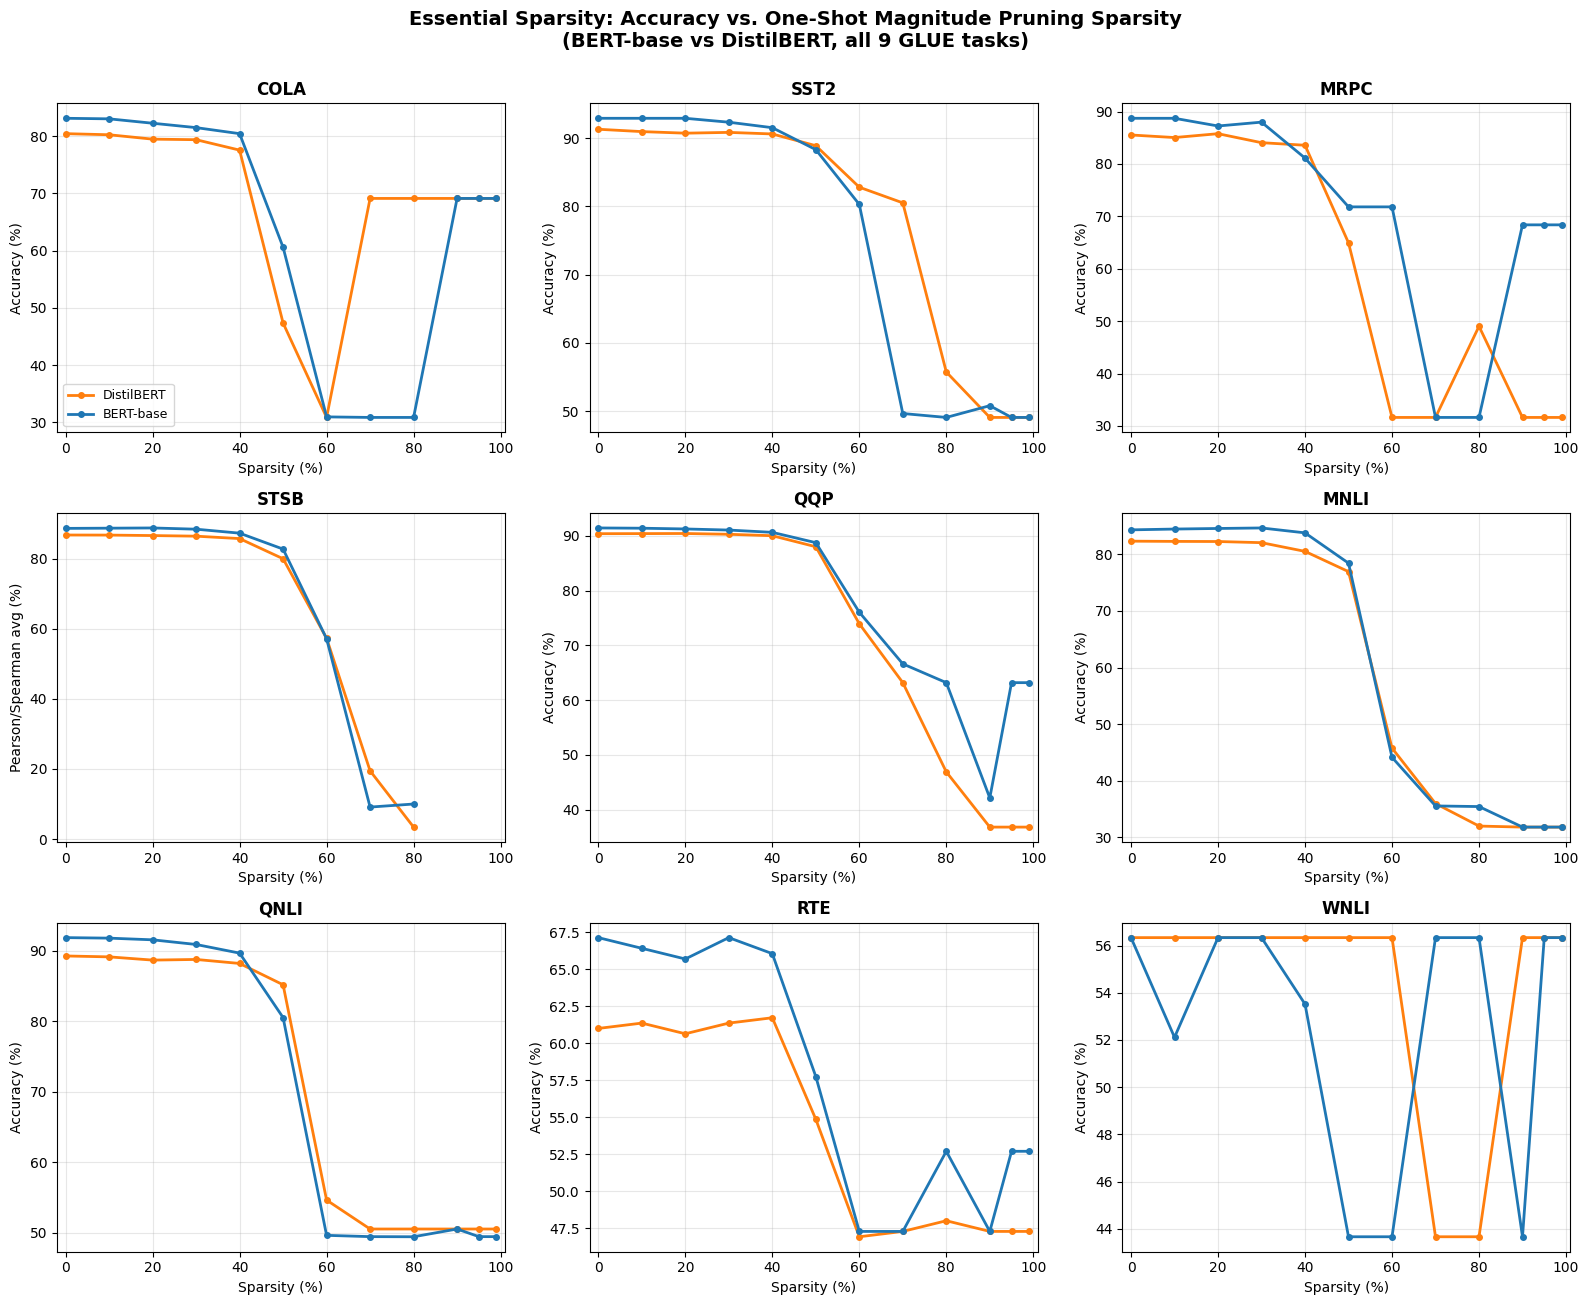

Saved: /content/drive/MyDrive/EmberSieve/reports/figures/sparsity_vs_accuracy_all_tasks.png

SPARSITY CLIFF SUMMARY (max sparsity within 5pp of dense accuracy)
     model task  dense_accuracy  max_safe_sparsity_%
DistilBERT COLA           80.44                 40.0
DistilBERT SST2           91.28                 50.0
DistilBERT MRPC           85.54                 40.0
DistilBERT STSB           86.73                 40.0
DistilBERT  QQP           90.38                 50.0
DistilBERT MNLI           82.32                 40.0
DistilBERT QNLI           89.24                 50.0
DistilBERT  RTE           61.01                 40.0
DistilBERT WNLI           56.34                 99.0
 BERT-base COLA           83.13                 40.0
 BERT-base SST2           92.89                 50.0
 BERT-base MRPC           88.73                 30.0
 BERT-base STSB           88.62                 40.0
 BERT-base  QQP           91.42                 50.0
 BERT-base MNLI           84.32              

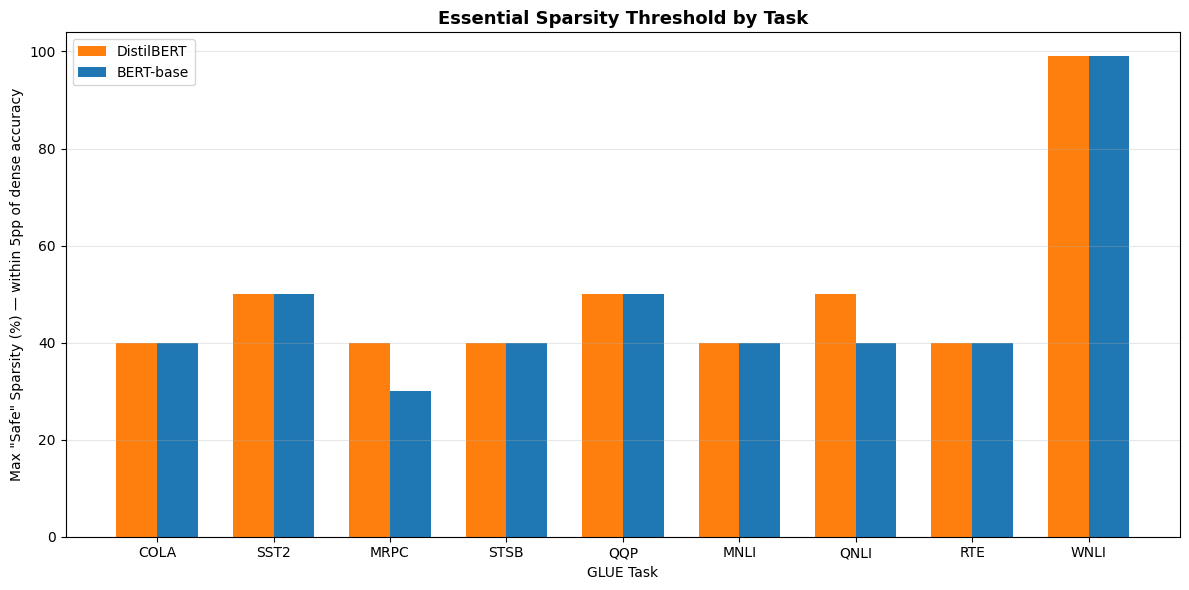

Saved: /content/drive/MyDrive/EmberSieve/reports/figures/sparsity_cliff_by_task.png


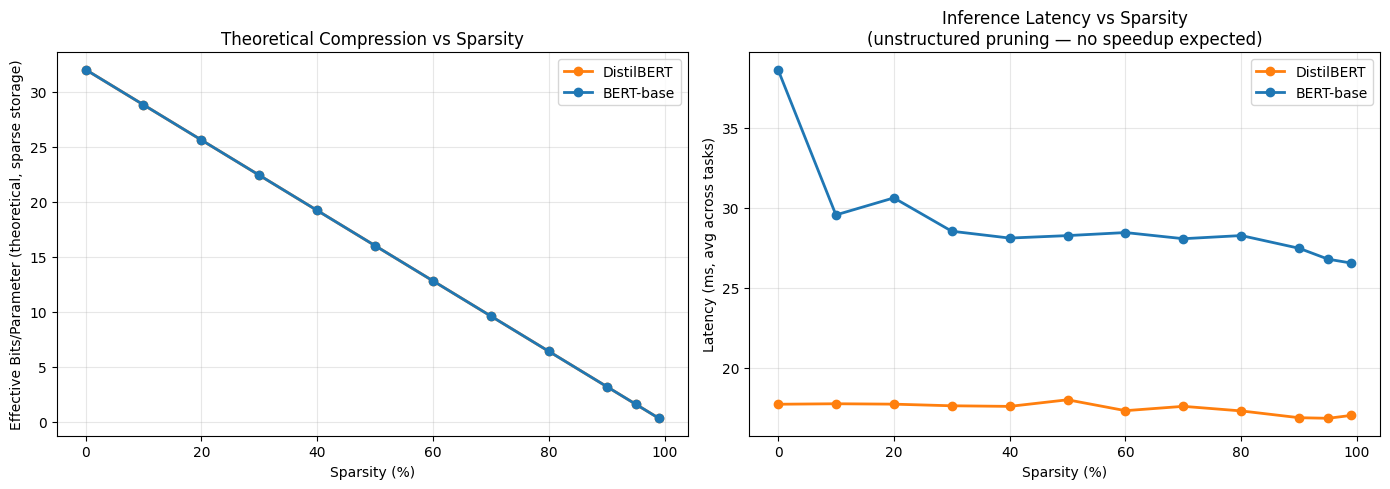

Saved: /content/drive/MyDrive/EmberSieve/reports/figures/memory_latency_tradeoff.png

CELL 13 COMPLETE — analysis and visualizations generated.


In [ ]:
# ============================================================
# CELL 13: Analysis & Visualizations
# Sparsity-vs-Accuracy curves, Sparsity Cliff detection,
# Memory/Latency trade-offs
# EmberSieve — Essential Sparsity Benchmarking
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

results_df = pd.read_csv(RESULTS_CSV)
FIGURES_DIR = os.path.join(PATHS["reports"], "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

MODEL_COLORS = {"bert-base": "#1f77b4", "distilbert": "#ff7f0e"}
MODEL_LABELS = {"bert-base": "BERT-base", "distilbert": "DistilBERT"}

# ---------------------------------------------------------
# 1. Sparsity vs Accuracy — one subplot per task, 3x3 grid
#    (STS-B uses "accuracy" column which we defined as the
#    avg of Pearson/Spearman — noted in the axis label)
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, task in enumerate(GLUE_TASKS):
    ax = axes[i]
    task_df = results_df[results_df["task"] == task].sort_values("sparsity")
    for model in MODEL_RUN_ORDER:
        sub = task_df[task_df["model"] == model]
        ax.plot(sub["sparsity"] * 100, sub["accuracy"] * 100,
                marker="o", markersize=4, linewidth=2,
                color=MODEL_COLORS[model], label=MODEL_LABELS[model])
    ax.set_title(task.upper(), fontsize=12, fontweight="bold")
    ax.set_xlabel("Sparsity (%)")
    ax.set_ylabel("Pearson/Spearman avg (%)" if task == "stsb" else "Accuracy (%)")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 101)
    if i == 0:
        ax.legend(loc="lower left", fontsize=9)

plt.suptitle("Essential Sparsity: Accuracy vs. One-Shot Magnitude Pruning Sparsity\n"
             "(BERT-base vs DistilBERT, all 9 GLUE tasks)", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
fig1_path = os.path.join(FIGURES_DIR, "sparsity_vs_accuracy_all_tasks.png")
plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig1_path}")

# ---------------------------------------------------------
# 2. Sparsity Cliff Detection — the core "essential sparsity"
#    finding: for each (model, task), find the highest sparsity
#    at which accuracy stays within 5 percentage points of the
#    dense baseline (a common threshold in the pruning literature).
# ---------------------------------------------------------
def find_sparsity_cliff(task_df, drop_threshold=0.05):
    """Returns the max sparsity level where accuracy is within
    `drop_threshold` (absolute) of the dense (sparsity=0) baseline."""
    task_df = task_df.sort_values("sparsity")
    dense_row = task_df[task_df["sparsity"] == 0.0]
    if len(dense_row) == 0 or pd.isna(dense_row["accuracy"].values[0]):
        return None, None
    dense_acc = dense_row["accuracy"].values[0]

    safe_sparsities = task_df[
        (task_df["accuracy"] >= dense_acc - drop_threshold) & (task_df["accuracy"].notna())
    ]["sparsity"]
    max_safe_sparsity = safe_sparsities.max() if len(safe_sparsities) > 0 else 0.0
    return max_safe_sparsity, dense_acc

cliff_rows = []
for model in MODEL_RUN_ORDER:
    for task in GLUE_TASKS:
        task_df = results_df[(results_df["model"] == model) & (results_df["task"] == task)]
        cliff_sparsity, dense_acc = find_sparsity_cliff(task_df)
        cliff_rows.append({
            "model": MODEL_LABELS[model], "task": task.upper(),
            "dense_accuracy": round(dense_acc * 100, 2) if dense_acc is not None else None,
            "max_safe_sparsity_%": round(cliff_sparsity * 100, 1) if cliff_sparsity is not None else None,
        })

cliff_df = pd.DataFrame(cliff_rows)
print("\n" + "=" * 70)
print("SPARSITY CLIFF SUMMARY (max sparsity within 5pp of dense accuracy)")
print("=" * 70)
print(cliff_df.to_string(index=False))

cliff_csv_path = os.path.join(PATHS["results"], "sparsity_cliff_summary.csv")
cliff_df.to_csv(cliff_csv_path, index=False)
print(f"\nSaved: {cliff_csv_path}")

# ---------------------------------------------------------
# 3. Sparsity Cliff bar chart — visual summary across all tasks
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(12, 6))
tasks_upper = [t.upper() for t in GLUE_TASKS]
x = np.arange(len(tasks_upper))
width = 0.35

for offset, model in zip([-width/2, width/2], MODEL_RUN_ORDER):
    vals = [cliff_df[(cliff_df["model"] == MODEL_LABELS[model]) & (cliff_df["task"] == t)]["max_safe_sparsity_%"].values[0]
            for t in tasks_upper]
    ax2.bar(x + offset, vals, width, label=MODEL_LABELS[model], color=MODEL_COLORS[model])

ax2.set_xlabel("GLUE Task")
ax2.set_ylabel("Max \"Safe\" Sparsity (%) — within 5pp of dense accuracy")
ax2.set_title("Essential Sparsity Threshold by Task", fontsize=13, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(tasks_upper)
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig2_path = os.path.join(FIGURES_DIR, "sparsity_cliff_by_task.png")
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig2_path}")

# ---------------------------------------------------------
# 4. Memory & Latency trade-off (effective_bits captures the
#    theoretical compression memory pruning would enable)
# ---------------------------------------------------------
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 5))

for model in MODEL_RUN_ORDER:
    sub = results_df[results_df["model"] == model].groupby("sparsity")["effective_bits"].mean().reset_index()
    ax3a.plot(sub["sparsity"] * 100, sub["effective_bits"], marker="o",
              color=MODEL_COLORS[model], label=MODEL_LABELS[model], linewidth=2)
ax3a.set_xlabel("Sparsity (%)")
ax3a.set_ylabel("Effective Bits/Parameter (theoretical, sparse storage)")
ax3a.set_title("Theoretical Compression vs Sparsity")
ax3a.grid(True, alpha=0.3)
ax3a.legend()

for model in MODEL_RUN_ORDER:
    sub = results_df[results_df["model"] == model].groupby("sparsity")["latency_ms"].mean().reset_index()
    ax3b.plot(sub["sparsity"] * 100, sub["latency_ms"], marker="o",
              color=MODEL_COLORS[model], label=MODEL_LABELS[model], linewidth=2)
ax3b.set_xlabel("Sparsity (%)")
ax3b.set_ylabel("Latency (ms, avg across tasks)")
ax3b.set_title("Inference Latency vs Sparsity\n(unstructured pruning — no speedup expected)")
ax3b.grid(True, alpha=0.3)
ax3b.legend()

plt.tight_layout()
fig3_path = os.path.join(FIGURES_DIR, "memory_latency_tradeoff.png")
plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig3_path}")

print("\nCELL 13 COMPLETE — analysis and visualizations generated.")

In [ ]:
# ============================================================
# CELL 14 (FINAL): Dense-Baseline Results Table (per Dataset/Model)
# + Energy Consumption (self-contained — defines its own
# measure_energy_consumption, does not depend on Cell 7 for it)
# EmberSieve — Essential Sparsity Benchmarking
# ============================================================

import pandas as pd
import time

# ---------------------------------------------------------
# STEP 0: Energy measurement function (self-contained)
# ---------------------------------------------------------
try:
    from codecarbon import EmissionsTracker
    _CODECARBON_AVAILABLE = True
except ImportError:
    _CODECARBON_AVAILABLE = False

def measure_energy_consumption(fn, *args, **kwargs):
    """Runs fn(*args, **kwargs) while measuring energy. Returns (result, energy_kwh)."""
    if _CODECARBON_AVAILABLE:
        tracker = EmissionsTracker(log_level="error", save_to_file=False, allow_multiple_runs=True)
        tracker.start()
        result = fn(*args, **kwargs)
        tracker.stop()
        energy_kwh = tracker._total_energy.kWh if hasattr(tracker, "_total_energy") else None
        return result, energy_kwh
    else:
        # Fallback: typical Colab T4 TDP (70W) x wall-clock time
        T4_TDP_KW = 0.070
        start = time.perf_counter()
        result = fn(*args, **kwargs)
        elapsed_hr = (time.perf_counter() - start) / 3600
        return result, T4_TDP_KW * elapsed_hr

print(f"Energy measurement ready. (codecarbon available: {_CODECARBON_AVAILABLE})")

# ---------------------------------------------------------
# STEP 1: Load results, define table structure
# ---------------------------------------------------------
results_df = pd.read_csv(RESULTS_CSV)
dense_df = results_df[results_df["sparsity"] == 0.0].copy()

TASK_DISPLAY_NAMES = {
    "sst2": "SST2", "qnli": "QNLI", "qqp": "QQP", "wnli": "WNLI",
    "mnli": "MNLI", "mrpc": "MRPC", "stsb": "STS-B", "rte": "RTE", "cola": "COLA",
}
MODEL_DISPLAY_NAMES = {"bert-base": "BERT-base", "distilbert": "DistilBERT"}
TABLE_TASK_ORDER = ["sst2", "qnli", "qqp", "wnli", "mnli", "mrpc", "stsb", "rte", "cola"]

# ---------------------------------------------------------
# STEP 2: Backfill Energy Consumption for each dense model.
# Resumable: skips any (model, task) pair already measured.
# ---------------------------------------------------------
ENERGY_CSV = os.path.join(PATHS["results"], "energy_consumption.csv")

if os.path.exists(ENERGY_CSV):
    energy_df = pd.read_csv(ENERGY_CSV)
    print(f"Loaded existing energy measurements: {len(energy_df)} rows")
else:
    energy_df = pd.DataFrame(columns=["model", "task", "energy_kwh"])

def energy_already_measured(model_name, task_name):
    return len(energy_df[(energy_df["model"] == model_name) & (energy_df["task"] == task_name)]) > 0

print("=" * 60)
print("BACKFILLING ENERGY CONSUMPTION (dense models only)")
print("=" * 60)

for task_name in TABLE_TASK_ORDER:
    for model_name in MODEL_RUN_ORDER:
        if energy_already_measured(model_name, task_name):
            print(f"[{model_name}/{task_name}] already measured — skipping.")
            continue

        tokenizer = get_tokenizer(MODEL_CHECKPOINTS[model_name])
        model = load_dense_model_robust(model_name, task_name)

        _, energy_kwh = measure_energy_consumption(
            measure_latency_throughput, model, tokenizer, n_iters=30
        )
        new_row = pd.DataFrame([{"model": model_name, "task": task_name, "energy_kwh": energy_kwh}])
        energy_df = pd.concat([energy_df, new_row], ignore_index=True)
        energy_df.to_csv(ENERGY_CSV, index=False)
        print(f"[{model_name}/{task_name}] energy = {energy_kwh:.8f} kWh")

        del model
        torch.cuda.empty_cache()

print(f"\nEnergy measurements saved to: {ENERGY_CSV}")

# ---------------------------------------------------------
# STEP 3: Merge energy into dense_df, print formatted table
# ---------------------------------------------------------
dense_df = dense_df.merge(energy_df, on=["model", "task"], how="left")

print("\n" + "=" * 70)
print("FORMATTED TABLE ")
print("=" * 70)

for task_name in TABLE_TASK_ORDER:
    print(f"\nDataset name: {TASK_DISPLAY_NAMES[task_name]}")
    print("Model name\tMemory Size\tLatency\tAccuracy\tBits\tPrecision\tRecall\tF1-score\tThroughput\tEnergy Consumption")
    for model_name in ["bert-base", "distilbert"]:
        row = dense_df[(dense_df["model"] == model_name) & (dense_df["task"] == task_name)]
        if len(row) == 0:
            print(f"{MODEL_DISPLAY_NAMES[model_name]}\tMISSING ROW")
            continue
        r = row.iloc[0]
        precision_str = f"{r['precision']*100:.2f}%" if not pd.isna(r['precision']) else "N/A"
        recall_str = f"{r['recall']*100:.2f}%" if not pd.isna(r['recall']) else "N/A"
        f1_str = f"{r['f1_score']*100:.2f}%" if not pd.isna(r['f1_score']) else "N/A"
        energy_str = f"{r['energy_kwh']:.8f} kWh" if not pd.isna(r.get('energy_kwh')) else "N/A"
        print(f"{MODEL_DISPLAY_NAMES[model_name]}\t"
              f"{r['memory_size_mb']:.2f} MB\t"
              f"{r['latency_ms']:.2f} ms\t"
              f"{r['accuracy']*100:.2f}%\t"
              f"{int(r['nominal_bits'])}-bit\t"
              f"{precision_str}\t{recall_str}\t{f1_str}\t"
              f"{r['throughput_samples_per_sec']:.2f} samples/sec\t"
              f"{energy_str}")

# ---------------------------------------------------------
# STEP 4: Save clean CSV for Excel/Word import
# ---------------------------------------------------------
table_export = dense_df[["task", "model", "memory_size_mb", "latency_ms", "accuracy",
                          "nominal_bits", "precision", "recall", "f1_score",
                          "throughput_samples_per_sec", "energy_kwh"]].copy()
table_export["task"] = table_export["task"].map(TASK_DISPLAY_NAMES)
table_export["model"] = table_export["model"].map(MODEL_DISPLAY_NAMES)
table_export.columns = ["Dataset", "Model", "Memory Size (MB)", "Latency (ms)", "Accuracy",
                          "Bits", "Precision", "Recall", "F1-score",
                          "Throughput (samples/sec)", "Energy Consumption (kWh)"]
table_export.to_csv(os.path.join(PATHS["results"], "dense_baseline_table.csv"), index=False)
print(f"\nSaved formatted table to: {PATHS['results']}/dense_baseline_table.csv")

print("\nCELL 14 COMPLETE.")

Energy measurement ready. (codecarbon available: True)
BACKFILLING ENERGY CONSUMPTION (dense models only)


[codecarbon WARNING @ 17:41:24] Multiple instances of codecarbon are allowed to run at the same time.
/tmp/ipykernel_2122/3296758937.py:84: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_df = pd.concat([energy_df, new_row], ignore_index=True)


[distilbert/sst2] energy = 0.00012261 kWh


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[bert-base/sst2] energy = 0.00008568 kWh
[distilbert/qnli] energy = 0.00004928 kWh
[bert-base/qnli] energy = 0.00008580 kWh
[distilbert/qqp] energy = 0.00004943 kWh
[bert-base/qqp] energy = 0.00008760 kWh
[distilbert/wnli] energy = 0.00005244 kWh
[bert-base/wnli] energy = 0.00009254 kWh
[distilbert/mnli] energy = 0.00004979 kWh
[bert-base/mnli] energy = 0.00008839 kWh
[distilbert/mrpc] energy = 0.00005028 kWh
[bert-base/mrpc] energy = 0.00008857 kWh
[distilbert/stsb] energy = 0.00005138 kWh
[bert-base/stsb] energy = 0.00008938 kWh
[distilbert/rte] energy = 0.00005068 kWh
[bert-base/rte] energy = 0.00009056 kWh
[distilbert/cola] energy = 0.00005088 kWh
[bert-base/cola] energy = 0.00009067 kWh

Energy measurements saved to: /content/drive/MyDrive/EmberSieve/results/energy_consumption.csv

FORMATTED TABLE (copy-paste ready)

Dataset name: SST2
Model name	Memory Size	Latency	Accuracy	Bits	Precision	Recall	F1-score	Throughput	Energy Consumption
BERT-base	417.66 MB	27.54 ms	92.89%	32-bit	92.